In [3]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:55886


In [10]:
@pf.parametric_component
def create_mrr(*, port_spec, coupling_distance=0.6, coupling_length=5.35, radius=10):
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    ring_coupler = pf.parametric.ring_coupler(
        port_spec=port_spec, 
        coupling_distance=coupling_distance,
        coupling_length=coupling_length,
        radius=radius, 
        bus_length=radius,
        tidy3d_model_kwargs={
            # These symmetries are not correct for arbitrary ports.
            # They can be used in this case for the fundamental mode.
            "port_symmetries": [
                ("P2", "P3", "P0", "P1"),
            ],
        },
    )

    component = pf.Component("component")
    
    bottom_coupler_ref = component.add_reference(ring_coupler)
    top_coupler_ref = component.add_reference(ring_coupler)
    
    bottom_coupler_ref.connect("P1", top_coupler_ref["P3"])
    bottom_coupler_ref.connect("P3", top_coupler_ref["P1"])

    component.add_port(component.detect_ports([port_spec]))
    component.add_model(pf.CircuitModel(), "Circuit")

    return component

mrr = create_mrr(port_spec="TE_1550_500")
viewer(mrr)

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\parametric_utils.py:208: RuntimeWarning: Component function '__main__.create_mrr' previously registered will be overwritten.
  return _decorator(decorated_function)


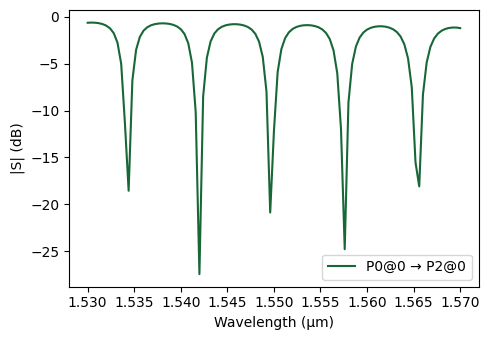

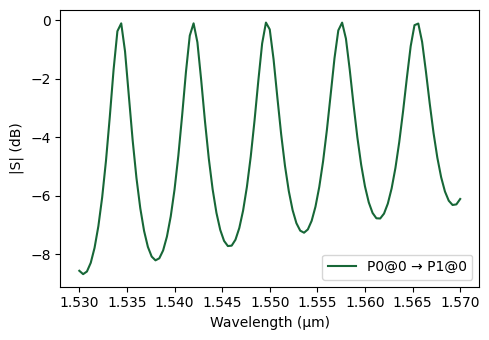

In [12]:
component = create_mrr(port_spec="TE_1550_500")

s_matrix = component.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P2"], y="dB")
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P1"], y="dB")